<a href="https://colab.research.google.com/github/fabiankmroh/aistudy/blob/master/multiclass_short_import.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
new_model_train = False
model_type = "MLP"
dataset = "MNIST"

In [7]:
transform = transforms.ToTensor()
train_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train = True, download = True, transform = transform)
test_DS = datasets.MNIST(root = '/content/drive/MyDrive/Colab Notebooks/data', train = False, download = True, transform = transform)

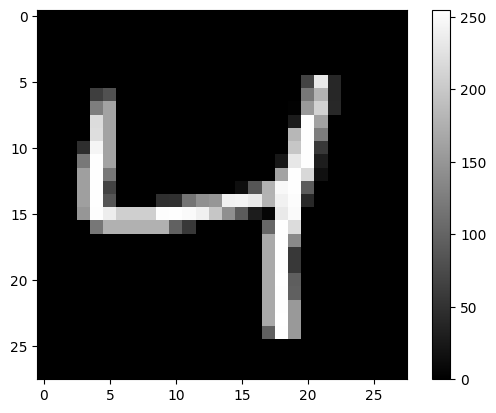

In [8]:
plt.imshow(train_DS.data[2], cmap = "gray")
plt.colorbar()

In [9]:
train_DL = torch.utils.data.DataLoader(train_DS, batch_size = BATCH_SIZE, shuffle = True)
test_DL = torch.utils.data.DataLoader(test_DS, batch_size = BATCH_SIZE, shuffle = True)

In [10]:
train_DL.dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content/drive/MyDrive/Colab Notebooks/data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [11]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.fcs = nn.Sequential(
        nn.Linear(28*28, 30),
        nn.BatchNorm1d(30),
        nn.ReLU(),
        nn.Linear(30, 10)
    )

  def forward(self, x):
    x = torch.flatten(x, start_dim = 1)
    x = self.fcs(x)
    return x

In [12]:
model = globals()[model_type]().to(DEVICE) # Globals --> Change Model Type Globally
print(model)

MLP(
  (fcs): Sequential(
    (0): Linear(in_features=784, out_features=30, bias=True)
    (1): BatchNorm1d(30, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=30, out_features=10, bias=True)
  )
)


In [13]:
BATCH_SIZE = 32
LR = 1e-3
EPOCH = 5
criterion = nn.CrossEntropyLoss()
# This Cell Must be Below Model Declaration
optimizer = optim.Adam(model.parameters(), lr = LR) # FORGOT TO DECLARE

In [14]:
x_batch, _ = next(iter(train_DL))
print(x_batch.shape)
print(model(x_batch.to(DEVICE)).shape)

torch.Size([32, 1, 28, 28])
torch.Size([32, 10])


In [15]:
if new_model_train:
  optimizer = optim.Adam(model.parameters(), lr = LR)
  loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

  torch.save(model, save_model_path)

  plt.plot(range(1, EPOCH + 1), loss_history)
  plt.xlabel("Epochs")
  plt.ylabel("Loss")

  plt.title("Train Loss")
  plt.grid()

In [16]:
def Train(model, train_DL, criterion, optimizer, EPOCH):
  NoT = len(train_DL.dataset) # Number of Training Data
  loss_history = []

  model.train()
  for ep in range(EPOCH):
    rloss = 0
    for x_batch, y_batch in train_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      pred = model(x_batch) # Prediction / Inference
      loss = criterion(pred, y_batch) # Loss

      optimizer.zero_grad() # Reset Gradient
      loss.backward() # Backpropagation
      optimizer.step() # Weight Update

      # Loss Accumulation
      loss_b = loss.item() * x_batch.shape[0] # Batch Loss
      rloss += loss_b # Running Loss

    # Print Loss
    loss_e = rloss / NoT
    loss_history += [loss_e]

    print(f"Epoch {ep + 1} - Training Loss: {loss_e:.3f}")
    print("-"*30)

  return loss_history

In [17]:
def Test(model, test_DL):
  model.eval()

  with torch.no_grad():
    rcorrect = 0

    for x_batch, y_batch in test_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      # Inference
      y_hat = model(x_batch)

      pred = y_hat.argmax(dim = 1)
      corrects_b = torch.sum(pred == y_batch).item()
      rcorrect += corrects_b

    accuracy = rcorrect / len(test_DL.dataset) * 100

  print(f"Test Accuracy: {rcorrect} / {len(test_DL.dataset)} - {accuracy:.1f} %")

  return accuracy

In [18]:
loss_history = Train(model, train_DL, criterion, optimizer, EPOCH)

Epoch 1 - Training Loss: 0.395
------------------------------
Epoch 2 - Training Loss: 0.200
------------------------------
Epoch 3 - Training Loss: 0.165
------------------------------
Epoch 4 - Training Loss: 0.146
------------------------------
Epoch 5 - Training Loss: 0.130
------------------------------


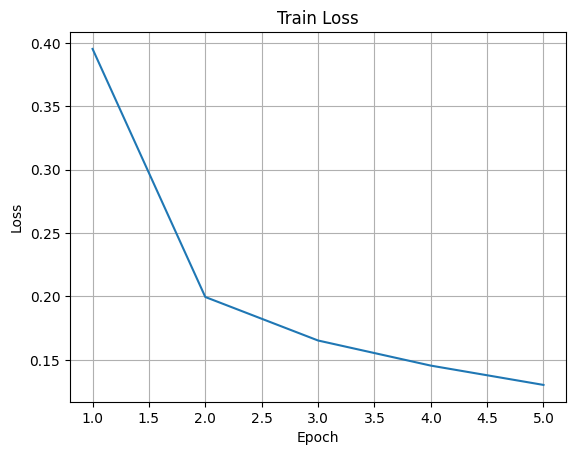

In [19]:
plt.plot(range(1, EPOCH + 1), loss_history)

plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid()

In [20]:
Test(model, test_DL)

Test Accuracy: 9656 / 10000 - 96.6 %


96.56

In [21]:
def Test_plot(model, test_DL):
  model.eval()
  with torch.no_grad():
    x_batch, y_batch = next(iter(test_DL))
    x_batch = x_batch.to(DEVICE)

    y_hat = model(x_batch)
    pred = y_hat.argmax(dim = 1)

  x_batch = x_batch.to("cpu")

  plt.figure(figsize = (8,4))
  for idx in range(6):
    plt.subplot(2,3, idx+1, xticks = [], yticks = [])
    plt.imshow(x_batch[idx].permute(1,2,0).squeeze(), cmap = "gray")

    pred_class = test_DL.dataset.classes[pred[idx]]
    true_class = test_DL.dataset.classes[y_batch[idx]]

    plt.title(f"{pred_class} ({true_class})", color = "g" if pred_class == true_class else "r")

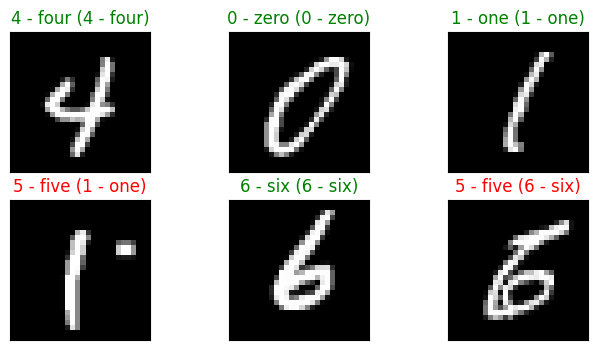

In [22]:
Test_plot(model, test_DL)

In [23]:
# Parameter Numbers
def count_params(model):
  num = sum([p.numel() for p in model.parameters() if p.requires_grad])
  return num

In [24]:
print(count_params(model))

23920


In [26]:
# Confusion Matrix
def get_conf(model, test_DL):
  N = len(test_DL.dataset.classes)
  model.eval()

  with torch.no_grad():
    confusion = torch.zeros(N,N)

    for x_batch, y_batch in test_DL:
      x_batch = x_batch.to(DEVICE)
      y_batch = y_batch.to(DEVICE)

      y_hat = model(x_batch) # Inference
      pred = y_hat.argmax(dim = 1) # Accuracy

      confusion += torch.bincount(N * y_batch.cpu() + pred.cpu(), minlength = N ** 2).reshape(N, N)

  confusion = confusion.numpy()

  return confusion

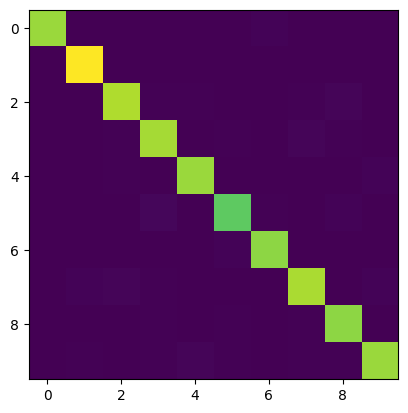

In [27]:
confusion = get_conf(model, test_DL)
plt.imshow(confusion)

In [29]:
import numpy as np

def plot_confusion_matrix(confusion, classes = None):
  N = confusion.shape[0]
  accuracy = np.trace(confusion) / np.sum(confusion) * 100

  plt.figure(figsize = (10,7))
  plt.imshow(confusion, cmap = "Blues")
  plt.title("Confusion Matrix")
  plt.colorbar()

  for i in range(N):
    for j in range(N):
      plt.text(j, i, round(confusion[i, j]),
               horizontalalignment = "center", fontsize = 10,
               color = "white" if confusion[i, j] > np.max(confusion) / 1.5 else "black")

  if classes is not None:
    plt.xticks(range(N), classes)
    plt.yticks(range(N), classes)
  else:
    plt.xticks(range(N))
    plt.yticks(range(N))

  plt.xlabel("Predicted")
  plt.ylabel("True")

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '0 - zero'),
  Text(1, 0, '1 - one'),
  Text(2, 0, '2 - two'),
  Text(3, 0, '3 - three'),
  Text(4, 0, '4 - four'),
  Text(5, 0, '5 - five'),
  Text(6, 0, '6 - six'),
  Text(7, 0, '7 - seven'),
  Text(8, 0, '8 - eight'),
  Text(9, 0, '9 - nine')])

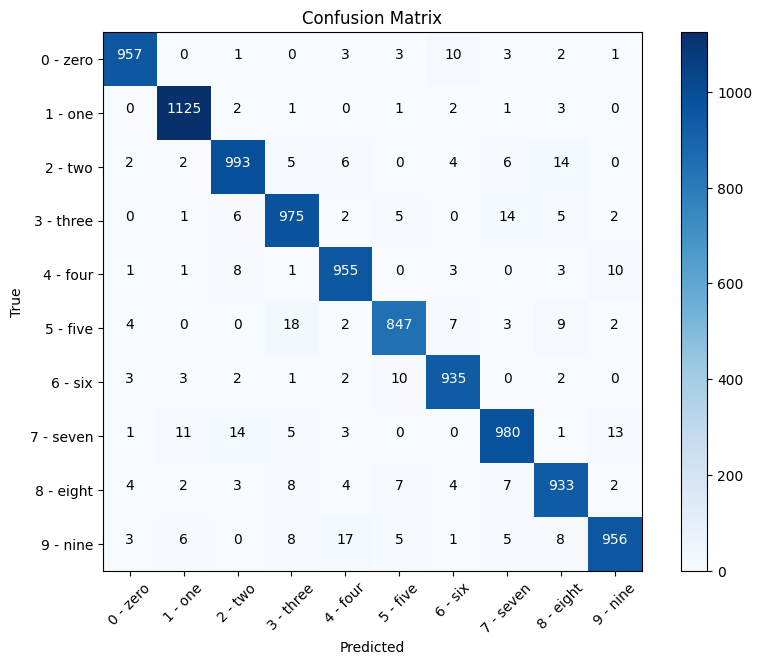

In [30]:
confusion = get_conf(model, test_DL)
plot_confusion_matrix(confusion, test_DL.dataset.classes)
plt.xticks(rotation = 45)